# 1.暂退法
在上一节中。我们了解通过惩罚权重的$L_2$范数来正则化统计模型的经典方法。在概率论角度看，我们可以通过以下论证来证明这一技术的合理性：我们已经假设了一个先验，即全中国的值取自均值为0的高斯分布。更直观的是，我们希望模型深度挖掘特征，即将权重分散到许多特征中，而不是过于依赖潜在的虚假关联。

## 1.1 重新审视过拟合
当面对更多的特征而样本不足时，线性模型往往会过拟合。相反，当给出更多样本而不是特征时，通常线性模型不会过拟合。遗憾的是，线性模型泛化的可靠性是有代价的。简单地说，线性模型没有考虑到特征之间的交互作用。对于每个特征，线性模型必须指定正的或负的权重，而忽略其他特征。</br>
泛化性和灵活性之间的这种基本权衡被描述为**偏差-方差权衡**。线性模型有很大的偏差：它们只能表示一小类函数(线性模型的假设空间（它能表达的所有函数的集合）非常小。如果真实函数不在这类函数中，模型就注定有偏差。)然而，这些模型的方差很小：他们在不同的数据样本上可以得出相似的结果（线性模型的形状被严格限定为“直线/超平面”，只有斜率（权重）和截距可以调整。）。

**偏差：** 模型的平均预测与真实值之间的距离。高偏差意味着模型对真实规律拟合得不够准，即使给它很多不同数据，它也总是“固执己见”。</br>
**方差：** 模型在不同训练集上的预测结果的变化程度。高方差意味着模型对训练数据非常敏感，换一组数据，预测结果就大不相同。

深度神经网络与线性模型不同，它并不局限于单独查看每个特征，而是学习特征之间的交互。例如：神经网络可能推断“尼日利亚”和“西联汇款”一起出现在电子邮件表示垃圾邮件，但单独出现则不表示垃圾邮件。</br>
而即使我们有比特征多得多的样本，深度神经网络也有可能过拟合。

## 1.2 扰动的稳健性
首先，我们所认为的“好”的预测模型应该是能在位置的数据上有好的表现。经典泛化理论认为，为了缩小训练性能和测试性能之间的差距，应该以简单的模型为目标。**简单性**以较小维度的形式展现。正如我们之前讨论的**$L_2$正则化** 的那样，参数的范数也代表了一种有用的简单性度量。</br>
简单性的另一种角度是**平滑性**，即函数不应该对其输入的微小变化敏感。例如，在早期做对图像分类时，我们预计向像素添加一些随机噪声应该是基本无影响的。而在1995年毕晓普用数学证明：**“要求函数平滑”和“要求函数对输入的随机噪声具有适应性”之间的联系。**
</br>
在2014年，斯里瓦斯塔瓦等人就如何将毕晓普的想法应用于网络的内部层提出了一个想法：在训练过程中，它们建议在计算后续层之前向网络的每一层注入噪声，因为当训练一个有多层的深度网络时，注入噪声只会在输入-输出映射上增强平滑性。这个想法称为**暂退法。暂退法在前向传播过程中，计算每一内部层的同时注入噪声，这已成为训练神经网络的常用技术。**

需要说明的是，暂退法的原始论文提到了一个关于有性繁殖的类比：**神经网络过拟合与每一层都依赖前一层的激活值有关**，这种情况称为“共适应性”。而暂退法会破坏共适应性，就像有性生殖会破坏共适应性的基因一样。</br>
那么关键的挑战就是如何注入这种噪声。一种想法是以一种**无偏**的方式注入噪声。这样在固定其他层时，每一层的期望值等于没有噪声时的值。

在毕晓普的工作中，他将高斯噪声添加到线性模型的输入中。在每次训练迭代中，他将从均值为0的分布$\epsilon ~ N(0, \sigma ^ 2)$中抽样噪声并添加到输入x，从而产生扰动点$x^{'} = x + \epsilon$，期望时$E[x^{'}] = x$

在标准暂退法正则化中，通过按保留（未丢弃）的节点的分数进行规范化来消除每一层的偏差。换言之，每个中间激活值h以暂退概率P被随机变量$h^{'}$替换，如下所示：
$$
h^{'} = \left\{\begin{matrix}
 0, \ \ \ \ \ 概率为P \\
\frac{h}{1-p}, \ 其他情况
\end{matrix}\right.
$$
根据此模型的设计，其期望保持不变，即$E[h^{'}] = h$。

## 1.3 实践中的暂退法
在第一节的多层感知机中有1个隐藏层和5个隐藏单元的多层感知机。当我们将暂退法应用到隐藏层，以p的概率将隐藏单元置为零时，结果可以看作一个只包含原始神经元子集的网络。
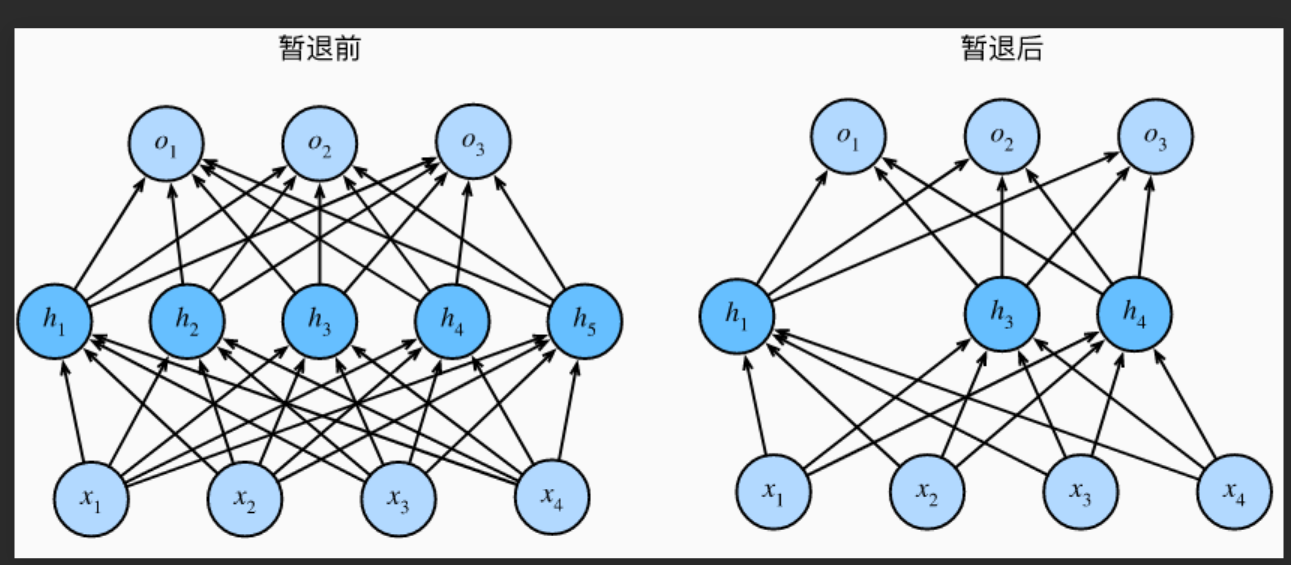


比如上图中，删除了$h_2$和$h_5$，因此输出的计算不再依赖这两个单元，并且它们各自的梯度在执行反向传播时也会消失。这样，输出层的计算不能过度依赖$h_1,...,h_5$中的任何一个元素。

通常我们在测试时不同暂退法。给定一个训练好的模型和新的样本，我们不会丢弃任何节点，因此不需要标准化。然而也有一些例外，一些研究人员在测试时使用暂退法，用于估计神经网络的“不确定性”：**如果通过许多不同的暂退法遮盖后得到的预测结果都是一致的，那么我们可以说网络表现更稳定。**

具体好处总结如下：</br>
1. 破坏共适应性</br>
神经元无法依赖固定的“伙伴”，被迫独立学习有用特征</br>
网络学习到的是更鲁棒、更分散的特征表示，而非针对训练集的特定模式</br>

2. 相当于集成学习 </br>
每次 Dropout 相当于训练一个不同的子网络</br>
整个训练过程相当于隐式地训练了指数级多个子网络的集成</br>
测试时使用完整网络，相当于这些子网络的“平均预测”</br>

3. 减少对特定特征的依赖</br>
网络不能依赖某个特征总是存在</br>
迫使模型学习更通用的模式</br>




## 1.4 从零开始实现
实现单层的暂退法函数，我们从均匀分布$U[0, 1]$中抽取样本，样本数与这层神经网络的维度一致。然后我们保留哪些对应样本大于P的节点，把剩下节点丢弃。

In [3]:
import torch
from torch import nn
from d2l import torch as d2l

def dropout_layer(X, dropout):
    assert 0 <= dropout <= 1 # 断言语句，确保 dropout 参数在合法范围内
    # 在这个情况中，所有元素都被丢弃，dropout为概率
    if dropout == 1:
        return torch.zeros_like(X)
    # 在这个情况中，所有元素都被保留
    if dropout == 0:
        return X
    mask = (torch.rand(X.shape) > dropout).float()
    """
    生成与 X 形状相同的张量，每个元素是 [0, 1) 区间内均匀分布的随机数；
    
    > dropout，对随机数张量进行逐元素比较，结果是一个布尔张量（True/False），
    含义：如果随机数 > dropout，则该位置为 True（保留）；否则为 False（丢弃）；

    
    """
    return mask * X / (1.0 - dropout)

In [4]:
X = torch.arange(16, dtype = torch.float32).reshape((2, 8))
print(X)
print(dropout_layer(X, 0.))
print(dropout_layer(X, 0.5))
print(dropout_layer(X, 1.))

tensor([[ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11., 12., 13., 14., 15.]])
tensor([[ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11., 12., 13., 14., 15.]])
tensor([[ 0.,  0.,  4.,  6.,  8., 10., 12., 14.],
        [16.,  0.,  0.,  0., 24., 26., 28.,  0.]])
tensor([[0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.]])


### 1. 定义模型参数
我们使用2.5节中引入的Fashion-MNIST数据集。我们定义具有两个隐藏层的多层感知机，每个隐藏层包含256个隐藏单元。

In [5]:
num_inputs, num_outputs, num_hiddens1, num_hiddens2 = 784, 10, 256, 265

### 2. 定义模型
我们可以将暂退法应用于每个隐藏层的输出（激活层之后），并且可以为每一层分别设置暂退概率：**常用技巧是在靠近输入层的地方设置较低的暂退概率。**

In [ ]:
dropout1, dropout2 = 0.2, 0.5

class Net(nn.Module):
    def __init__(self, num_inputs, num_outputs, num_hiddens1, num_hiddens2, is_training = True):
        super(Net, self).__init__()
        self.num_inputs = num_inputs
        self.training = is_training
        self.lin1 = nn.Linear(num_inputs, num_hiddens1)
        self.lin2 = nn.Linear(num_hiddens1, num_hiddens2)
        self.lin3 = nn.Linear(num_hiddens2, num_outputs)
        self.relu = nn.ReLU()

    def forward(self, X):
        H1 = self.relu(self.lin1(X.reshape((-1, self.num_inputs))))
        # 只有在训练模型时才使用暂退法
        if self.training == True:
            # 在第一个全连接层之后添加一个暂退层
            H1 = dropout_layer(H1, dropout1)
        H2 = self.relu(self.)